In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
model=YOLO('/mnt/d/Computer-Vision/Projects/project4/yolo26s.pt')
video_path = '/mnt/d/Computer-Vision/Projects/project4/2.mp4'

In [3]:
region_points = [(20, 400), (1080, 400), (1080, 360), (20, 360)]
center = [590,400]

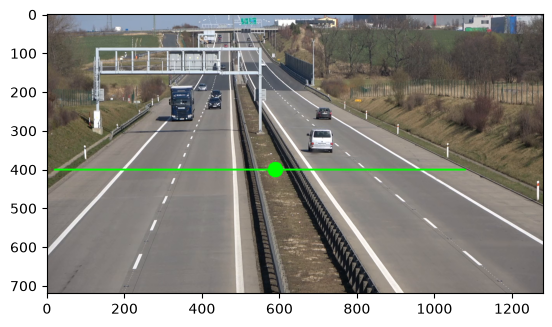

In [4]:
cap = cv2.VideoCapture(video_path)
ans , frame = cap.read()
image_show = cv2.line(frame , region_points[0],region_points[1],(0,255,0),4)
image_show = cv2.cvtColor(image_show , cv2.COLOR_BGR2RGB)
image_show = cv2.circle(image_show,center,5,(0,255,0),30)
plt.imshow(image_show)
plt.show()

In [5]:
ans , frame = cap.read()
result = model.track(frame,persist=True,show=False)


0: 384x640 2 cars, 6.9ms
Speed: 47.4ms preprocess, 6.9ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)


In [6]:
result[0].boxes.id

tensor([1., 2.], device='cuda:0')

In [7]:
result[0].boxes.xywh

tensor([[713.7606, 254.6280,  42.9789,  31.8440],
        [401.8578, 187.2155,  25.5262,  20.2307]], device='cuda:0')

In [8]:
previous_positions = {}

cap = cv2.VideoCapture(video_path)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter('output.mp4',fourcc, fps,(width, height))

car_count_right = 0
car_count_left = 0 
id_list = []

while cap.isOpened():

    ans, frame = cap.read()

    # اگر ویدیو تمام شد
    if not ans:
        break

    result = model.track(frame, persist=True, show=False)

    key = cv2.waitKey(1)
    if key == ord('q'):
        break

    for i in range(len(result[0])):

        if result[0].boxes.id is not None:

            box = result[0].boxes.xywh.cpu().numpy()[i]
            object_id = int(result[0].boxes.id.cpu().numpy()[i])

            cx = box[0]
            cy = box[1]

            if object_id in previous_positions:

                previous_cx, previous_cy = previous_positions[object_id]

                crossed_line = (previous_cy < center[1] and cy >= center[1]) or (previous_cy > center[1] and cy <= center[1])

                if crossed_line and object_id not in id_list:
                    if cx < center[0]:
                        car_count_left += 1
                    elif cx > center[0]:
                        car_count_right += 1

                    id_list.append(object_id)

            previous_positions[object_id] = (cx, cy)

    frame_result = cv2.line(frame,region_points[0],region_points[1],(0, 0, 200),4)
    frame_result = cv2.rectangle(frame_result,(20, 20),(260, 170),(0, 0, 0),-1)
    frame_result = cv2.putText(frame_result,f'right:{car_count_right}',(40, 70),cv2.FONT_HERSHEY_COMPLEX_SMALL,1.5,(255, 255, 255),3)
    frame_result = cv2.putText(frame_result,f'left:{car_count_left}',(40, 140),cv2.FONT_HERSHEY_COMPLEX_SMALL,1.5,(255, 255, 255),3)
    cv2.imshow('camera', frame_result)
    out.write(frame_result)


out.release()
cap.release()
cv2.destroyAllWindows()


0: 384x640 2 cars, 7.0ms
Speed: 2.2ms preprocess, 7.0ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 7.6ms
Speed: 1.4ms preprocess, 7.6ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 11.7ms
Speed: 1.5ms preprocess, 11.7ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)



QObject::moveToThread: Current thread (0x47a15c00) is not the object's thread (0x89c9a4a0).
Cannot move to target thread (0x47a15c00)

QObject::moveToThread: Current thread (0x47a15c00) is not the object's thread (0x89c9a4a0).
Cannot move to target thread (0x47a15c00)

QObject::moveToThread: Current thread (0x47a15c00) is not the object's thread (0x89c9a4a0).
Cannot move to target thread (0x47a15c00)

QObject::moveToThread: Current thread (0x47a15c00) is not the object's thread (0x89c9a4a0).
Cannot move to target thread (0x47a15c00)

QObject::moveToThread: Current thread (0x47a15c00) is not the object's thread (0x89c9a4a0).
Cannot move to target thread (0x47a15c00)

QObject::moveToThread: Current thread (0x47a15c00) is not the object's thread (0x89c9a4a0).
Cannot move to target thread (0x47a15c00)

QObject::moveToThread: Current thread (0x47a15c00) is not the object's thread (0x89c9a4a0).
Cannot move to target thread (0x47a15c00)

QObject::moveToThread: Current thread (0x47a15c00) is n

0: 384x640 3 cars, 17.5ms
Speed: 3.2ms preprocess, 17.5ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 12.4ms
Speed: 3.3ms preprocess, 12.4ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 10.4ms
Speed: 3.4ms preprocess, 10.4ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 12.4ms
Speed: 2.7ms preprocess, 12.4ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 13.1ms
Speed: 2.9ms preprocess, 13.1ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 11.6ms
Speed: 2.3ms preprocess, 11.6ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 12.6ms
Speed: 2.1ms preprocess, 12.6ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 14.7ms
Speed: 1.6ms preprocess, 14.7ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x6